In [1]:
from unityagents import UnityEnvironment
import numpy as np
import random
import torch
from collections import deque
import matplotlib.pyplot as plt
%matplotlib inline

from deep_rl.agent.DDPG_agent import DDPGAgent

In [2]:
#Loading Environment 
env = UnityEnvironment(file_name="Tennis_Windows_x86_64/Tennis_Windows_x86_64/Tennis.exe") 

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


In [4]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

In [5]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents 
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

print(brain.vector_observation_space_size)
print(state_size)
print(brain.vector_action_space_size)

Number of agents: 2
Size of each action: 2
There are 2 agents. Each observes a state with length: 24
The state for the first agent looks like: [ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.         -6.65278625 -1.5
 -0.          0.          6.83172083  6.         -0.          0.        ]
8
24
2


# Training

In [6]:
# create a new agent
agent = DDPGAgent(state_size=state_size, action_size=brain.vector_action_space_size, random_seed=1)

In [7]:
#Just for debug/display purpose
print(state_size)

24


In [8]:
#Just for debug/display purpose
actions = np.random.randn(num_agents, action_size)
print(actions)

[[-2.24010492 -1.29153387]
 [-0.8838953  -0.5307024 ]]


In [9]:
#Just for debug/display purpose
noise_factor = 0.1
env_info = env.reset(train_mode=True)[brain_name]
states = env_info.vector_observations
print(states)
print(states.shape)
actions = agent.act(states, noise_factor=noise_factor)
print(actions)

[[ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.         -7.38993645 -1.5
  -0.          0.          6.83172083  5.99607611 -0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.         -6.70024681 -1.5
   0.          0.         -6.83172083  5.99607611  0.          0.        ]]
(2, 24)
[[ 0.03440508 -0.00063448]
 [ 0.04507908 -0.01415111]]


In [10]:
def train_maddpg(n_episodes=2000, max_t=1000, print_every=50):
    scores_deque = deque(maxlen=print_every)
    scores = []
    best_score = -np.inf
    noise_factor = 0.15  # A factor to multiply random noise
    for i_episode in range(1, n_episodes+1):
        env_info = env.reset(train_mode=True)[brain_name]
        states = env_info.vector_observations # states.shape is (2,24). env_reset returned state of both tennis players
        scores_agents = np.zeros(2)  # the scores of both tennis agents after an episode
        agent.reset()
        for t in range(max_t):
            
            # The Agent selects Actions
            # actions for both the agents (both tennis players)
            if i_episode < 20:
                actions = np.random.randn(num_agents, action_size)  # use random actions for the first 100 episodes
            else:
                actions = agent.act(states, noise_factor=noise_factor)
            
            # Actions of the other player
            actions_other_player = np.flip(actions, 0)
            
            # Environment processes the Action; produces new State, Rewards
            env_info = env.step(actions)[brain_name]      
            rewards = env_info.rewards                    
            next_states = env_info.vector_observations
            next_states_other_player = np.flip(next_states, 0)
            dones = env_info.local_done 
            
            # The Agent learns
            #agent.step(states, actions, rewards, next_states, dones)
            agent.step(states, actions, actions_other_player, rewards, next_states, next_states_other_player, dones) 
            
            states = next_states
            scores_agents += rewards
            if np.any(dones):
                break 
        avg_score = np.mean(scores_agents)  # the average score of the agents
        max_score = np.max(scores_agents)  # the max score of the agents
        #scores_deque.append(avg_score)
        scores_deque.append(max_score)
        #scores.append(avg_score)
        scores.append(max_score)
        
        #noise reduced during training as episodes progresses
        noise_factor = max(0.999 * noise_factor, 0.02)
        
        #print('\rEpisode {:d}\tscore: {:.2f}\taverage score over the last 10 episodes: {:.2f}'.format(i_episode, scores_deque[-1], np.mean(list(scores_deque)[-10:])), end="")
        print('\rEpisode {:d}\tmax score: {:.2f}\tavg max score over the last 10 episodes: {:.2f}'.format(i_episode, scores_deque[-1], np.mean(list(scores_deque)[-10:])), end="")
        #if i_episode % 10 == 0:
            #torch.save(agent.actor_local.state_dict(), 'weights/checkpoint_actor_{:d}_{:.2f}.pth'.format(i_episode, scores_deque[-1]))
            #torch.save(agent.critic_local.state_dict(), 'weights/checkpoint_critic_{:d}_{:.2f}.pth'.format(i_episode, scores_deque[-1]))
        
        if i_episode > 100 and np.mean(scores_deque) > 0.5 and np.mean(scores_deque) > best_score:
            best_score = np.mean(scores_deque)
            torch.save(agent.actor_local.state_dict(), 'weights/checkpoint_actor.pth')
            torch.save(agent.critic_local.state_dict(), 'weights/checkpoint_critic.pth')
            print('\nEnvironment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(i_episode-100, np.mean(scores_deque)))
        
            break

        if i_episode % print_every == 0:
            print('\rEpisode {}\tAvg Score: {:.2f}'.format(i_episode, np.mean(scores_deque)))
            
    return scores

scores = train_maddpg()

Episode 50	Avg Score: 0.01	avg max score over the last 10 episodes: 0.00
Episode 100	Avg Score: 0.02	avg max score over the last 10 episodes: 0.04
Episode 150	Avg Score: 0.06	avg max score over the last 10 episodes: 0.08
Episode 200	Avg Score: 0.09	avg max score over the last 10 episodes: 0.09
Episode 250	Avg Score: 0.10	avg max score over the last 10 episodes: 0.10
Episode 300	Avg Score: 0.14	avg max score over the last 10 episodes: 0.22
Episode 323	max score: 0.30	avg max score over the last 10 episodes: 0.48
Environment solved in 223 episodes!	Average Score: 0.50


In [11]:
#close the environment
env.close()

# Score vs Episode

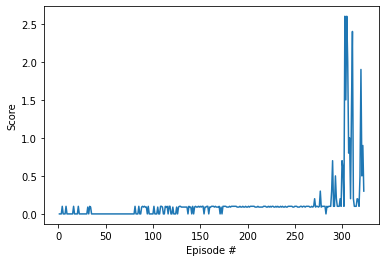

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.plot(np.arange(1, len(scores)+1), scores)
plt.ylabel('Score')
plt.xlabel('Episode #')
plt.show()

# Performance Testing

Creating Unity environment with worker_id=30...


INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


✓ Environment created successfully on attempt 1

Environment Info:
- Number of agents: 2
- Action size: 2
- State size: 24

Loading trained agent...
✓ Successfully loaded trained weights

Testing trained agent for 10 episodes

Episode  1: Max Score =  0.100, Agent Scores = [-0.010,  0.100], Length =   31 steps
Episode  2: Max Score =  2.600, Agent Scores = [ 2.490,  2.600], Length =  983 steps
Episode  3: Max Score =  0.000, Agent Scores = [ 0.000, -0.010], Length =   13 steps
Episode  4: Max Score =  2.600, Agent Scores = [ 2.600,  2.600], Length = 1000 steps (timeout)
Episode  5: Max Score =  2.700, Agent Scores = [ 2.600,  2.700], Length = 1000 steps (timeout)
Episode  6: Max Score =  2.600, Agent Scores = [ 2.600,  2.600], Length = 1000 steps (timeout)
Episode  7: Max Score =  0.200, Agent Scores = [ 0.200,  0.090], Length =   54 steps
Episode  8: Max Score =  0.090, Agent Scores = [ 0.000,  0.090], Length =   31 steps
Episode  9: Max Score =  0.100, Agent Scores = [ 0.100, -0.010]

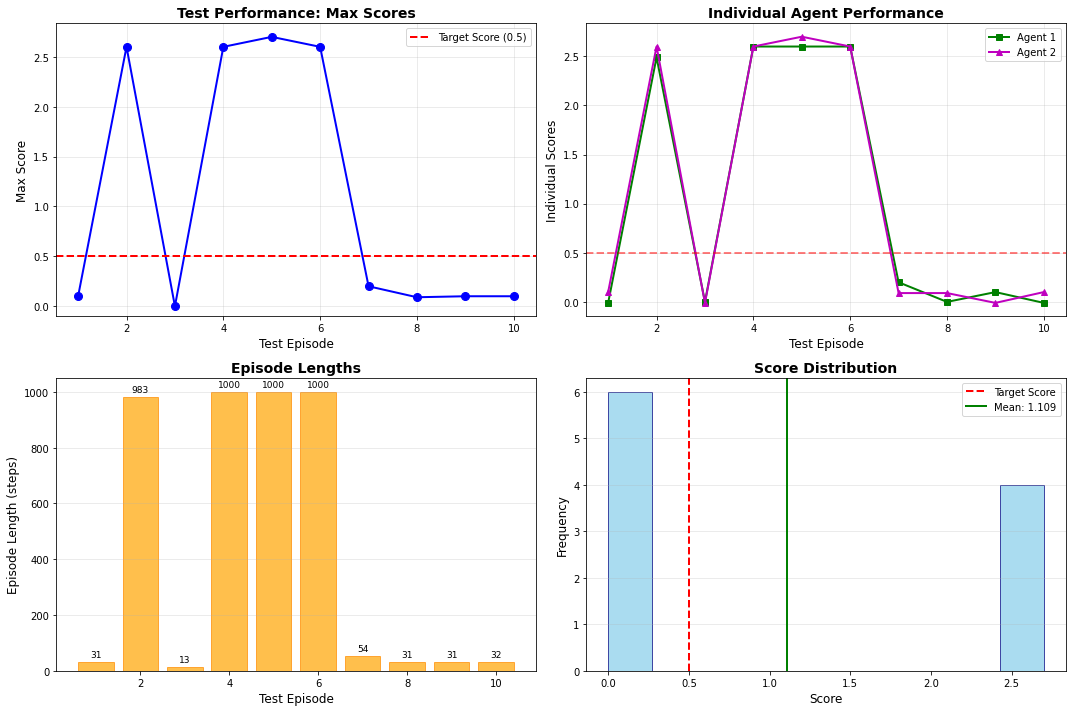


Closing environment...
Testing complete!

Save test results to file? (y/n): y
Results saved to test_results_20250603_214940.txt


In [1]:
import os
import numpy as np
import torch
from unityagents import UnityEnvironment
from deep_rl.agent.DDPG_agent import DDPGAgent
import matplotlib.pyplot as plt
import random
import time

# Check if weights exist
if not os.path.exists('weights/checkpoint_actor.pth'):
    print("ERROR: Could not find trained weights at 'weights/checkpoint_actor.pth'")
    print("Please make sure you've trained the agent and saved the weights first.")
    exit()

# Use random worker_id to avoid connection conflicts
worker_id = random.randint(1, 99)
print(f"Creating Unity environment with worker_id={worker_id}...")

# Try to create environment with error handling
env = None
max_attempts = 5

for attempt in range(max_attempts):
    try:
        env = UnityEnvironment(
            file_name="Tennis_Windows_x86_64/Tennis.exe", 
            worker_id=worker_id + attempt  # Increment worker_id each attempt
        )
        print(f"✓ Environment created successfully on attempt {attempt + 1}")
        break
    except Exception as e:
        print(f"✗ Attempt {attempt + 1} failed: {str(e)[:100]}...")
        if attempt < max_attempts - 1:
            print(f"  Trying again with worker_id={worker_id + attempt + 1}...")
            time.sleep(2)
        else:
            print("\nFailed to create environment after all attempts.")
            print("Please:")
            print("1. Check Task Manager and end any 'Tennis.exe' processes")
            print("2. Wait a few seconds and try again")
            exit()

# Get environment information
brain_name = env.brain_names[0]
brain = env.brains[brain_name]
env_info = env.reset(train_mode=False)[brain_name]
num_agents = len(env_info.agents)
action_size = brain.vector_action_space_size
state_size = env_info.vector_observations.shape[1]

print(f"\nEnvironment Info:")
print(f"- Number of agents: {num_agents}")
print(f"- Action size: {action_size}")
print(f"- State size: {state_size}")

# Create agent and load trained weights
print("\nLoading trained agent...")
agent = DDPGAgent(state_size=state_size, action_size=action_size, random_seed=1)

try:
    # Load the saved weights
    agent.actor_local.load_state_dict(torch.load('weights/checkpoint_actor.pth'))
    agent.critic_local.load_state_dict(torch.load('weights/checkpoint_critic.pth'))
    print("✓ Successfully loaded trained weights")
except Exception as e:
    print(f"✗ Error loading weights: {e}")
    env.close()
    exit()

# Put networks in evaluation mode
agent.actor_local.eval()
agent.critic_local.eval()

# Test the trained agent
n_test_episodes = 10
max_t = 1000
episode_scores = []
episode_lengths = []
agent_scores = []  # Store individual agent scores

print(f"\n{'='*60}")
print(f"Testing trained agent for {n_test_episodes} episodes")
print(f"{'='*60}\n")

for ep in range(1, n_test_episodes + 1):
    env_info = env.reset(train_mode=False)[brain_name]
    states = env_info.vector_observations
    agent.reset()
    
    scores = np.zeros(num_agents)
    
    for t in range(1, max_t + 1):
        # Get actions from trained agent (no noise for testing)
        actions = agent.act(states, noise_factor=0.0)
        
        # Step the environment
        env_info = env.step(actions)[brain_name]
        next_states = env_info.vector_observations
        rewards = env_info.rewards
        dones = env_info.local_done
        
        scores += rewards
        states = next_states
        
        if np.any(dones):
            max_score = np.max(scores)
            print(f"Episode {ep:2d}: Max Score = {max_score:6.3f}, "
                  f"Agent Scores = [{scores[0]:6.3f}, {scores[1]:6.3f}], "
                  f"Length = {t:4d} steps")
            episode_scores.append(max_score)
            episode_lengths.append(t)
            agent_scores.append(scores.copy())
            break
    else:
        max_score = np.max(scores)
        print(f"Episode {ep:2d}: Max Score = {max_score:6.3f}, "
              f"Agent Scores = [{scores[0]:6.3f}, {scores[1]:6.3f}], "
              f"Length = {max_t:4d} steps (timeout)")
        episode_scores.append(max_score)
        episode_lengths.append(max_t)
        agent_scores.append(scores.copy())

# Calculate statistics
agent_scores = np.array(agent_scores)
print(f"\n{'='*60}")
print(f"PERFORMANCE SUMMARY")
print(f"{'='*60}")
print(f"Max Score Statistics:")
print(f"  Mean:  {np.mean(episode_scores):6.3f} ± {np.std(episode_scores):6.3f}")
print(f"  Min:   {np.min(episode_scores):6.3f}")
print(f"  Max:   {np.max(episode_scores):6.3f}")
print(f"\nIndividual Agent Statistics:")
print(f"  Agent 1 Mean: {np.mean(agent_scores[:, 0]):6.3f} ± {np.std(agent_scores[:, 0]):6.3f}")
print(f"  Agent 2 Mean: {np.mean(agent_scores[:, 1]):6.3f} ± {np.std(agent_scores[:, 1]):6.3f}")
print(f"\nEpisode Statistics:")
print(f"  Episodes Solved (>0.5):  {np.sum(np.array(episode_scores) > 0.5)} / {n_test_episodes}")
print(f"  Mean Episode Length:     {np.mean(episode_lengths):.1f} steps")
print(f"  Success Rate:            {100 * np.sum(np.array(episode_scores) > 0.5) / n_test_episodes:.1f}%")
print(f"{'='*60}")

# Visualize results
fig = plt.figure(figsize=(15, 10))

# Plot 1: Episode scores
ax1 = plt.subplot(2, 2, 1)
ax1.plot(range(1, n_test_episodes + 1), episode_scores, 'b-', linewidth=2, marker='o', markersize=8)
ax1.axhline(y=0.5, color='r', linestyle='--', linewidth=2, label='Target Score (0.5)')
ax1.set_xlabel('Test Episode', fontsize=12)
ax1.set_ylabel('Max Score', fontsize=12)
ax1.set_title('Test Performance: Max Scores', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(bottom=-0.1)

# Plot 2: Individual agent scores
ax2 = plt.subplot(2, 2, 2)
ax2.plot(range(1, n_test_episodes + 1), agent_scores[:, 0], 'g-', linewidth=2, marker='s', label='Agent 1')
ax2.plot(range(1, n_test_episodes + 1), agent_scores[:, 1], 'm-', linewidth=2, marker='^', label='Agent 2')
ax2.axhline(y=0.5, color='r', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Test Episode', fontsize=12)
ax2.set_ylabel('Individual Scores', fontsize=12)
ax2.set_title('Individual Agent Performance', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Episode lengths
ax3 = plt.subplot(2, 2, 3)
bars = ax3.bar(range(1, n_test_episodes + 1), episode_lengths, color='orange', alpha=0.7, edgecolor='darkorange')
ax3.set_xlabel('Test Episode', fontsize=12)
ax3.set_ylabel('Episode Length (steps)', fontsize=12)
ax3.set_title('Episode Lengths', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, length) in enumerate(zip(bars, episode_lengths)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(length)}', ha='center', va='bottom', fontsize=9)

# Plot 4: Score distribution
ax4 = plt.subplot(2, 2, 4)
ax4.hist(episode_scores, bins=10, color='skyblue', alpha=0.7, edgecolor='navy')
ax4.axvline(x=0.5, color='r', linestyle='--', linewidth=2, label='Target Score')
ax4.axvline(x=np.mean(episode_scores), color='g', linestyle='-', linewidth=2, label=f'Mean: {np.mean(episode_scores):.3f}')
ax4.set_xlabel('Score', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.set_title('Score Distribution', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')
ax4.legend()

plt.tight_layout()
plt.show()

# Clean up
print("\nClosing environment...")
env.close()
print("Testing complete!")

# Optional: Save test results
save_results = input("\nSave test results to file? (y/n): ").lower().strip() == 'y'
if save_results:
    import datetime
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"test_results_{timestamp}.txt"
    
    with open(filename, 'w') as f:
        f.write(f"Test Results - {timestamp}\n")
        f.write(f"{'='*60}\n")
        f.write(f"Number of test episodes: {n_test_episodes}\n")
        f.write(f"Mean score: {np.mean(episode_scores):.3f} ± {np.std(episode_scores):.3f}\n")
        f.write(f"Min/Max scores: {np.min(episode_scores):.3f} / {np.max(episode_scores):.3f}\n")
        f.write(f"Success rate: {100 * np.sum(np.array(episode_scores) > 0.5) / n_test_episodes:.1f}%\n")
        f.write(f"\nDetailed Results:\n")
        for i, (score, length) in enumerate(zip(episode_scores, episode_lengths)):
            f.write(f"Episode {i+1}: Score={score:.3f}, Length={length}\n")
    
    print(f"Results saved to {filename}")

# Running code for 1400 episodes for better results 

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


Starting Enhanced Multi-Agent Training...

Episode 50	Max: 0.00	Avg: 0.00	Success: 0%	Length: 14

Episode 50 Summary:
  Average Score: 0.00
  Success Rate: 0.0%
  Agent 1 Avg: -0.00
  Agent 2 Avg: -0.00
  Noise Factor: 0.1427

Episode 100	Max: 0.00	Avg: 0.00	Success: 0%	Length: 14

Episode 100 Summary:
  Average Score: 0.00
  Success Rate: 0.0%
  Agent 1 Avg: -0.00
  Agent 2 Avg: -0.01
  Noise Factor: 0.1357

Episode 150	Max: 0.00	Avg: 0.00	Success: 0%	Length: 14

Episode 150 Summary:
  Average Score: 0.00
  Success Rate: 0.0%
  Agent 1 Avg: -0.01
  Agent 2 Avg: -0.00
  Noise Factor: 0.1291

Episode 200	Max: 0.10	Avg: 0.02	Success: 0%	Length: 33

Episode 200 Summary:
  Average Score: 0.02
  Success Rate: 0.0%
  Agent 1 Avg: 0.01
  Agent 2 Avg: -0.00
  Noise Factor: 0.1228

Episode 250	Max: 0.00	Avg: 0.02	Success: 0%	Length: 14

Episode 250 Summary:
  Average Score: 0.02
  Success Rate: 0.0%
  Agent 1 Avg: 0.01
  Agent 2 Avg: 0.01
  Noise Factor: 0.1168

Episode 300	Max: 0.00	Avg: 0.00	

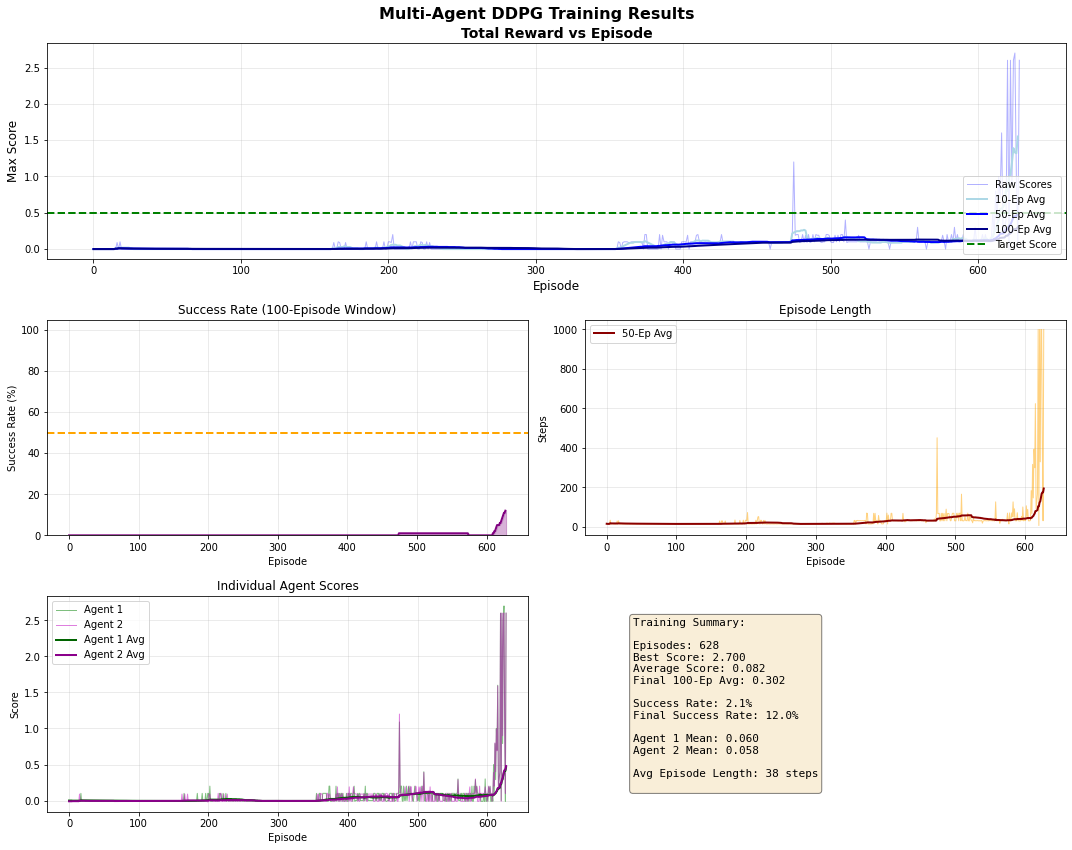

In [1]:
from unityagents import UnityEnvironment
import numpy as np
from collections import deque
import torch
import matplotlib.pyplot as plt
from deep_rl.agent.DDPG_agent import DDPGAgent

def train_maddpg_enhanced(n_episodes=2000, max_t=1000, print_every=50):
   
    
    # Standard tracking
    scores_deque = deque(maxlen=print_every)
    scores = []
    
    # Enhanced tracking for visualization
    agent1_scores = []
    agent2_scores = []
    episode_lengths = []
    
    best_score = -np.inf
    noise_factor = 0.15
    
    print("Starting Enhanced Multi-Agent Training...")
    print("="*60 + "\n")
    
    for i_episode in range(1, n_episodes+1):
        env_info = env.reset(train_mode=True)[brain_name]
        states = env_info.vector_observations
        scores_agents = np.zeros(2)
        agent.reset()
        
        for t in range(max_t):
            # The Agent selects Actions
            if i_episode < 20:
                actions = np.random.randn(num_agents, action_size)
            else:
                actions = agent.act(states, noise_factor=noise_factor)
            
            # Actions of the other player
            actions_other_player = np.flip(actions, 0)
            
            # Environment processes the Action; produces new State, Rewards
            env_info = env.step(actions)[brain_name]      
            rewards = env_info.rewards                    
            next_states = env_info.vector_observations
            next_states_other_player = np.flip(next_states, 0)
            dones = env_info.local_done 
            
            # The Agent learns
            agent.step(states, actions, actions_other_player, rewards, 
                      next_states, next_states_other_player, dones) 
            
            states = next_states
            scores_agents += rewards
            
            if np.any(dones):
                episode_lengths.append(t + 1)
                break 
        else:
            episode_lengths.append(max_t)
            
        # Track scores
        max_score = np.max(scores_agents)
        scores_deque.append(max_score)
        scores.append(max_score)
        agent1_scores.append(scores_agents[0])
        agent2_scores.append(scores_agents[1])
        
        # Reduce noise
        noise_factor = max(0.999 * noise_factor, 0.02)
        
        # Calculate metrics
        avg_score = np.mean(scores_deque)
        success_rate = sum(1 for s in scores[-100:] if s > 0.5) / min(100, len(scores)) * 100
        
        # Print progress
        print(f'\rEpisode {i_episode}\tMax: {max_score:.2f}\t'
              f'Avg: {avg_score:.2f}\tSuccess: {success_rate:.0f}%\t'
              f'Length: {episode_lengths[-1]}', end="")
        
        if i_episode % print_every == 0:
            print(f'\n\nEpisode {i_episode} Summary:')
            print(f'  Average Score: {avg_score:.2f}')
            print(f'  Success Rate: {success_rate:.1f}%')
            print(f'  Agent 1 Avg: {np.mean(agent1_scores[-print_every:]):.2f}')
            print(f'  Agent 2 Avg: {np.mean(agent2_scores[-print_every:]):.2f}')
            print(f'  Noise Factor: {noise_factor:.4f}\n')
        
        # Save best model
        if i_episode > 100 and avg_score > 0.5 and avg_score > best_score:
            best_score = avg_score
            torch.save(agent.actor_local.state_dict(), 'weights/checkpoint_actor.pth')
            torch.save(agent.critic_local.state_dict(), 'weights/checkpoint_critic.pth')
            print(f'\n\n🎉 Environment solved in {i_episode-100} episodes!\t'
                  f'Average Score: {avg_score:.2f}\n')
            break
    
    print("\n" + "="*60)
    print("Training Complete! Creating visualizations...")
    print("="*60 + "\n")
    
    # Create comprehensive plots
    create_training_plots(scores, agent1_scores, agent2_scores, episode_lengths)
    
    return scores

def create_training_plots(scores, agent1_scores, agent2_scores, episode_lengths):
    """Create comprehensive training visualizations"""
    
    episodes = range(1, len(scores) + 1)
    
    # Create main figure
    fig = plt.figure(figsize=(15, 12))
    
    # 1. Total Reward vs Episode (larger plot)
    ax1 = plt.subplot2grid((3, 2), (0, 0), colspan=2)
    ax1.plot(episodes, scores, 'b-', alpha=0.3, linewidth=1, label='Raw Scores')
    
    # Add multiple moving averages
    for window, color, style in [(10, 'lightblue', '-'), (50, 'blue', '-'), (100, 'darkblue', '-')]:
        if len(scores) >= window:
            ma = [np.mean(scores[max(0, i-window+1):i+1]) for i in range(len(scores))]
            ax1.plot(ma, color=color, linewidth=2, linestyle=style, label=f'{window}-Ep Avg')
    
    ax1.axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Target Score')
    ax1.set_xlabel('Episode', fontsize=12)
    ax1.set_ylabel('Max Score', fontsize=12)
    ax1.set_title('Total Reward vs Episode', fontsize=14, fontweight='bold')
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)
    
    # 2. Success Rate
    ax2 = plt.subplot2grid((3, 2), (1, 0))
    window = 100
    success_rates = []
    for i in range(len(scores)):
        start = max(0, i - window + 1)
        rate = sum(1 for s in scores[start:i+1] if s > 0.5) / (i - start + 1) * 100
        success_rates.append(rate)
    
    ax2.plot(success_rates, 'purple', linewidth=2)
    ax2.fill_between(episodes, 0, success_rates, alpha=0.3, color='purple')
    ax2.axhline(y=50, color='orange', linestyle='--', linewidth=2)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Success Rate (%)')
    ax2.set_title('Success Rate (100-Episode Window)')
    ax2.set_ylim([0, 105])
    ax2.grid(True, alpha=0.3)
    
    # 3. Episode Length
    ax3 = plt.subplot2grid((3, 2), (1, 1))
    ax3.plot(episode_lengths, 'orange', alpha=0.5, linewidth=1)
    if len(episode_lengths) >= 50:
        ma = [np.mean(episode_lengths[max(0, i-49):i+1]) for i in range(len(episode_lengths))]
        ax3.plot(ma, 'darkred', linewidth=2, label='50-Ep Avg')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Steps')
    ax3.set_title('Episode Length')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Individual Agent Performance
    ax4 = plt.subplot2grid((3, 2), (2, 0))
    ax4.plot(agent1_scores, 'g-', alpha=0.5, linewidth=1, label='Agent 1')
    ax4.plot(agent2_scores, 'm-', alpha=0.5, linewidth=1, label='Agent 2')
    if len(agent1_scores) >= 50:
        ma1 = [np.mean(agent1_scores[max(0, i-49):i+1]) for i in range(len(agent1_scores))]
        ma2 = [np.mean(agent2_scores[max(0, i-49):i+1]) for i in range(len(agent2_scores))]
        ax4.plot(ma1, 'darkgreen', linewidth=2, label='Agent 1 Avg')
        ax4.plot(ma2, 'darkmagenta', linewidth=2, label='Agent 2 Avg')
    ax4.set_xlabel('Episode')
    ax4.set_ylabel('Score')
    ax4.set_title('Individual Agent Scores')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # 5. Summary Statistics
    ax5 = plt.subplot2grid((3, 2), (2, 1))
    ax5.axis('off')
    
    summary = f"""Training Summary:
    
Episodes: {len(scores)}
Best Score: {max(scores):.3f}
Average Score: {np.mean(scores):.3f}
Final 100-Ep Avg: {np.mean(scores[-100:]):.3f}

Success Rate: {sum(s > 0.5 for s in scores) / len(scores) * 100:.1f}%
Final Success Rate: {success_rates[-1]:.1f}%

Agent 1 Mean: {np.mean(agent1_scores):.3f}
Agent 2 Mean: {np.mean(agent2_scores):.3f}

Avg Episode Length: {np.mean(episode_lengths):.0f} steps
"""
    
    ax5.text(0.1, 0.9, summary, transform=ax5.transAxes, fontsize=11,
            verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Multi-Agent DDPG Training Results', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run the enhanced training
if __name__ == "__main__":
    # Initialize environment (your existing code)
    env = UnityEnvironment(file_name="Tennis_Windows_x86_64/Tennis.exe")
    brain_name = env.brain_names[0]
    brain = env.brains[brain_name]
    
    env_info = env.reset(train_mode=True)[brain_name]
    num_agents = len(env_info.agents)
    action_size = brain.vector_action_space_size
    states = env_info.vector_observations
    state_size = states.shape[1]
    
    # Create agent
    agent = DDPGAgent(state_size=state_size, action_size=action_size, random_seed=1)
    
    # Run enhanced training with visualization
    scores = train_maddpg_enhanced(n_episodes=2000, max_t=1000, print_every=50)
    
    # Close environment
    env.close()

Above code Took 15 min to train 

# 2nd Iteration (With better success criteria and visualization)

In [3]:
!pip install seaborn

  Using cached pandas-1.1.5-cp36-cp36m-win_amd64.whl (8.7 MB)
  Using cached scipy-1.5.4-cp36-cp36m-win_amd64.whl (31.2 MB)


In [1]:
import numpy as np
import torch
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns
from unityagents import UnityEnvironment
from deep_rl.agent.DDPG_agent import DDPGAgent

sns.set(style="whitegrid", font_scale=1.15)

def train_maddpg_with_better_success(env, agent, brain_name, num_agents, action_size, n_episodes=2000, max_t=1000, print_every=50):
    scores = []
    scores_deque = deque(maxlen=print_every)
    agent1_scores = []
    agent2_scores = []
    episode_lengths = []
    episode_successes = []

    best_score = -np.inf
    noise_factor = 0.15
    solved = False

    print("Starting Enhanced Multi-Agent Training...")
    print("="*60)

    for i_episode in range(1, n_episodes+1):
        env_info = env.reset(train_mode=True)[brain_name]
        states = env_info.vector_observations
        scores_agents = np.zeros(num_agents)
        agent.reset()
        done = False

        for t in range(max_t):
            if i_episode < 20:
                actions = np.random.randn(num_agents, action_size)
            else:
                actions = agent.act(states, noise_factor=noise_factor)
            actions = np.clip(actions, -1, 1)

            # Interact with env
            env_info = env.step(actions)[brain_name]
            rewards = env_info.rewards
            next_states = env_info.vector_observations
            dones = env_info.local_done

            agent.step(states, actions, np.flip(actions, 0), rewards, next_states, np.flip(next_states, 0), dones)

            states = next_states
            scores_agents += rewards
            if np.any(dones):
                episode_lengths.append(t+1)
                break
        else:
            episode_lengths.append(max_t)

        # Track scores
        max_score = np.max(scores_agents)
        scores.append(max_score)
        agent1_scores.append(scores_agents[0])
        agent2_scores.append(scores_agents[1])

        # Success definition: episode is success if max agent score > 0.5 (modify if stricter needed)
        episode_successes.append(1 if max_score > 0.5 else 0)

        scores_deque.append(max_score)

        noise_factor = max(0.999 * noise_factor, 0.02)

        # Moving average success rate (last 100 episodes)
        success_rate = np.mean(episode_successes[-100:]) * 100

        print(f'\rEpisode {i_episode}\tMax: {max_score:.2f}\tAvg: {np.mean(scores_deque):.2f}\tSuccess: {success_rate:.0f}%\tLength: {episode_lengths[-1]}', end='')

        # Periodic summary
        if i_episode % print_every == 0:
            print(f'\n\nEpisode {i_episode} Summary:')
            print(f'  Average Score: {np.mean(scores_deque):.2f}')
            print(f'  Success Rate (100): {success_rate:.1f}%')
            print(f'  Agent 1 Avg: {np.mean(agent1_scores[-print_every:]):.2f}')
            print(f'  Agent 2 Avg: {np.mean(agent2_scores[-print_every:]):.2f}')
            print(f'  Noise Factor: {noise_factor:.4f}\n')

        # Environment solved criteria
        if not solved and i_episode > 100 and np.mean(scores_deque) > 0.5:
            solved = True
            torch.save(agent.actor_local.state_dict(), 'weights/checkpoint_actor.pth')
            torch.save(agent.critic_local.state_dict(), 'weights/checkpoint_critic.pth')
            print(f'\n\n🎉 Environment solved in {i_episode-100} episodes!\tAverage Score: {np.mean(scores_deque):.2f}\n')

    print("\n" + "="*60)
    print("Training Complete! Creating visualizations...")
    print("="*60 + "\n")
    # Visualize
    plot_training_results(
        scores, agent1_scores, agent2_scores, episode_lengths, episode_successes
    )
    return scores, agent1_scores, agent2_scores, episode_lengths, episode_successes

# --- PLOTTING FUNCTIONS ---

def plot_training_results(scores, agent1_scores, agent2_scores, episode_lengths, episode_successes):
    episodes = np.arange(1, len(scores) + 1)
    
    # --- 1. Total Reward vs Episode ---
    plt.figure(figsize=(10, 5))
    plt.plot(episodes, scores, color='dodgerblue', alpha=0.5, label='Raw Max Score')
    for window, color, label in [(10, 'skyblue', '10-Ep Avg'), (50, 'royalblue', '50-Ep Avg'), (100, 'navy', '100-Ep Avg')]:
        if len(scores) >= window:
            ma = [np.mean(scores[max(0, i-window+1):i+1]) for i in range(len(scores))]
            plt.plot(episodes, ma, color=color, linewidth=2, label=label)
    plt.axhline(y=0.5, color='green', linestyle='--', linewidth=2, label='Target Score')
    plt.title('Total Reward vs Episode')
    plt.xlabel('Episode')
    plt.ylabel('Max Score')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

    # --- 2. Success Rate ---
    window = 100
    moving_success = [np.mean(episode_successes[max(0, i-window+1):i+1]) * 100 for i in range(len(episode_successes))]
    plt.figure(figsize=(10, 5))
    plt.plot(episodes, moving_success, color='purple', linewidth=2, label=f'Success Rate ({window}-Ep MA)')
    plt.axhline(y=100, color='green', linestyle='--', linewidth=1.5, label='100%')
    plt.title('Success Rate Over Time')
    plt.xlabel('Episode')
    plt.ylabel('Success Rate (%)')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.ylim(0, 105)
    plt.tight_layout()
    plt.show()

    # --- 3. Episode Length ---
    plt.figure(figsize=(10, 5))
    plt.plot(episodes, episode_lengths, color='orange', alpha=0.4, label='Episode Length')
    if len(episode_lengths) >= 50:
        ma = [np.mean(episode_lengths[max(0, i-49):i+1]) for i in range(len(episode_lengths))]
        plt.plot(episodes, ma, color='red', linewidth=2, label='50-Ep Avg')
    plt.title('Episode Length Over Time')
    plt.xlabel('Episode')
    plt.ylabel('Steps')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

    # --- 4. Individual Agent Scores ---
    plt.figure(figsize=(10, 5))
    plt.plot(episodes, agent1_scores, color='green', alpha=0.4, label='Agent 1')
    plt.plot(episodes, agent2_scores, color='magenta', alpha=0.4, label='Agent 2')
    if len(agent1_scores) >= 50:
        ma1 = [np.mean(agent1_scores[max(0, i-49):i+1]) for i in range(len(agent1_scores))]
        ma2 = [np.mean(agent2_scores[max(0, i-49):i+1]) for i in range(len(agent2_scores))]
        plt.plot(episodes, ma1, color='darkgreen', linewidth=2, label='Agent 1 (50-Ep Avg)')
        plt.plot(episodes, ma2, color='darkmagenta', linewidth=2, label='Agent 2 (50-Ep Avg)')
    plt.title('Individual Agent Scores')
    plt.xlabel('Episode')
    plt.ylabel('Score')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

    # --- 5. Summary stats ---
    print("\n=== TRAINING SUMMARY ===")
    print(f"Episodes: {len(scores)}")
    print(f"Best Score: {np.max(scores):.3f}")
    print(f"Average Score: {np.mean(scores):.3f}")
    print(f"Final 100-Ep Avg: {np.mean(scores[-100:]):.3f}")
    print(f"Final Success Rate: {moving_success[-1]:.1f}%")
    print(f"Agent 1 Mean: {np.mean(agent1_scores):.3f}")
    print(f"Agent 2 Mean: {np.mean(agent2_scores):.3f}")
    print(f"Avg Episode Length: {np.mean(episode_lengths):.0f} steps")

# -------- MAIN TRAINING SCRIPT --------

if __name__ == "__main__":

    # Initialize Unity Environment (modify path as needed)
    env = UnityEnvironment(file_name="Tennis_Windows_x86_64/Tennis.exe")
    brain_name = env.brain_names[0]
    brain = env.brains[brain_name]

    env_info = env.reset(train_mode=True)[brain_name]
    num_agents = len(env_info.agents)
    action_size = brain.vector_action_space_size
    state_size = env_info.vector_observations.shape[1]

    # Create DDPG Agent (add params as needed for your agent implementation)
    agent = DDPGAgent(state_size=state_size, action_size=action_size, random_seed=1)
    
    # Train and visualize
    scores, agent1_scores, agent2_scores, episode_lengths, episode_successes = \
        train_maddpg_with_better_success(
            env, agent, brain_name, num_agents, action_size, n_episodes=2000, max_t=1000, print_every=50
        )
    env.close()

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		
Unity brain name: TennisBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 8
        Number of stacked Vector Observation: 3
        Vector Action space type: continuous
        Vector Action space size (per agent): 2
        Vector Action descriptions: , 


Starting Enhanced Multi-Agent Training...
Episode 50	Max: 0.10	Avg: 0.03	Success: 0%	Length: 31

Episode 50 Summary:
  Average Score: 0.03
  Success Rate (100): 0.0%
  Agent 1 Avg: 0.01
  Agent 2 Avg: 0.01
  Noise Factor: 0.1427

Episode 100	Max: 0.09	Avg: 0.06	Success: 0%	Length: 30

Episode 100 Summary:
  Average Score: 0.06
  Success Rate (100): 0.0%
  Agent 1 Avg: 0.02
  Agent 2 Avg: 0.03
  Noise Factor: 0.1357

Episode 150	Max: 0.09	Avg: 0.08	Success: 0%	Length: 31

Episode 150 Summary:
  Average Score: 0.08
  Success Rate (100): 0.0%
  Agent 1 Avg: 0.05
  Agent 2 Avg: 0.03
  Noise Factor: 0.1291

Episode 200	Max: 0.10	Avg: 0.07	Success: 0%	Length: 31

Episode 200 Summary:
  Average Score: 0.07
  Success Rate (100): 0.0%
  Agent 1 Avg: 0.04
  Agent 2 Avg: 0.03
  Noise Factor: 0.1228

Episode 250	Max: 0.09	Avg: 0.09	Success: 0%	Length: 31

Episode 250 Summary:
  Average Score: 0.09
  Success Rate (100): 0.0%
  Agent 1 Avg: 0.05
  Agent 2 Avg: 0.04
  Noise Factor: 0.1168

Episode 28

KeyboardInterrupt: 

# Plotting the training results 

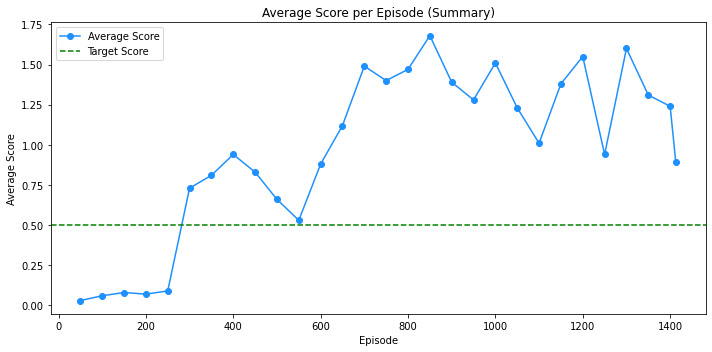

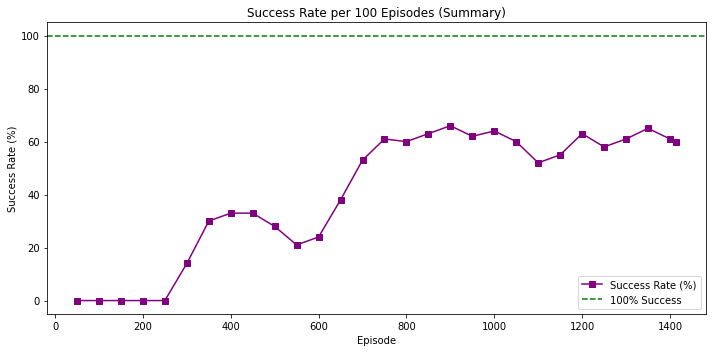

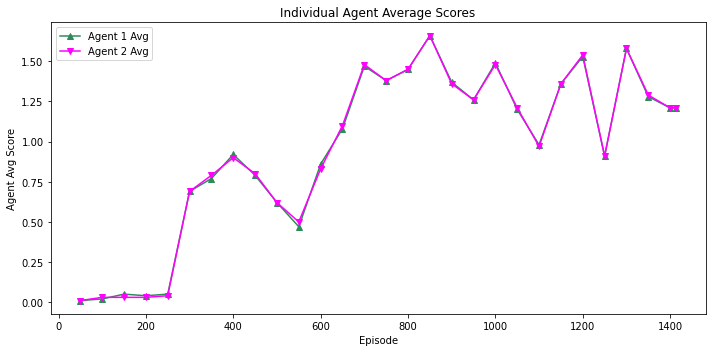


=== TRAINING SUMMARY ===
Episodes: 1413
Best Score: 1.680
Final Success Rate: 60.0%
Agent 1 Mean: 0.956
Agent 2 Mean: 0.956


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Manually parsed data from your logs (summaries every 50 episodes)
episodes = np.array([50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000, 1050, 1100, 1150, 1200, 1250, 1300, 1350, 1400, 1413])

avg_scores = np.array([
    0.03, 0.06, 0.08, 0.07, 0.09, 0.73, 0.81, 0.94, 0.83, 0.66, 0.53, 0.88, 1.12, 1.49, 1.40, 1.47, 1.68, 1.39, 1.28, 1.51, 1.23, 1.01, 1.38, 1.55, 0.94, 1.60, 1.31, 1.24, 0.89
])

success_rates = np.array([
    0.0, 0.0, 0.0, 0.0, 0.0, 14.0, 30.0, 33.0, 33.0, 28.0, 21.0, 24.0, 38.0, 53.0, 61.0, 60.0, 63.0, 66.0, 62.0, 64.0, 60.0, 52.0, 55.0, 63.0, 58.0, 61.0, 65.0, 61.0, 60.0
])

agent1_avgs = np.array([
    0.01, 0.02, 0.05, 0.04, 0.05, 0.69, 0.77, 0.92, 0.79, 0.62, 0.47, 0.86, 1.08, 1.47, 1.38, 1.45, 1.66, 1.37, 1.26, 1.49, 1.20, 0.98, 1.36, 1.53, 0.91, 1.58, 1.28, 1.21, 1.21
])

agent2_avgs = np.array([
    0.01, 0.03, 0.03, 0.03, 0.04, 0.69, 0.79, 0.90, 0.80, 0.62, 0.50, 0.83, 1.10, 1.48, 1.38, 1.45, 1.66, 1.36, 1.26, 1.48, 1.21, 0.97, 1.36, 1.54, 0.91, 1.58, 1.29, 1.21, 1.21
])

# You can extend these arrays with more points if you have more data!

# Plot: Average Score vs Episode
plt.figure(figsize=(10, 5))
plt.plot(episodes, avg_scores, marker='o', color='dodgerblue', label='Average Score')
plt.axhline(0.5, color='green', linestyle='--', label='Target Score')
plt.xlabel('Episode')
plt.ylabel('Average Score')
plt.title('Average Score per Episode (Summary)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot: Success Rate vs Episode
plt.figure(figsize=(10, 5))
plt.plot(episodes, success_rates, marker='s', color='purple', label='Success Rate (%)')
plt.axhline(100, color='green', linestyle='--', label='100% Success')
plt.xlabel('Episode')
plt.ylabel('Success Rate (%)')
plt.title('Success Rate per 100 Episodes (Summary)')
plt.legend()
plt.tight_layout()
plt.show()

# Plot: Agent 1 and Agent 2 Average Score vs Episode
plt.figure(figsize=(10, 5))
plt.plot(episodes, agent1_avgs, marker='^', color='seagreen', label='Agent 1 Avg')
plt.plot(episodes, agent2_avgs, marker='v', color='magenta', label='Agent 2 Avg')
plt.xlabel('Episode')
plt.ylabel('Agent Avg Score')
plt.title('Individual Agent Average Scores')
plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print("\n=== TRAINING SUMMARY ===")
print(f"Episodes: {episodes[-1]}")
print(f"Best Score: {np.max(avg_scores):.3f}")
print(f"Final Success Rate: {success_rates[-1]:.1f}%")
print(f"Agent 1 Mean: {np.mean(agent1_avgs):.3f}")
print(f"Agent 2 Mean: {np.mean(agent2_avgs):.3f}")
